# Análisis topológico del grafo de Internet a nivel de Sistemas Autónomos

Este notebook caracteriza la topología AS-level de Internet construida por
[`as-level-internet-graph`](https://github.com/valesteban/as-level-internet-graph) a partir de
tablas RIB de recolectores públicos (Route Views + RIPE RIS). Cada nodo es un ASN y cada arista
$(a, b)$ indica que los ASes $a$ y $b$ aparecieron **adyacentes en al menos un `AS_PATH`** observado
en la ventana de recolección; el atributo `weight` cuenta en cuántos paths se observó la adyacencia.

> **Lectura BGP del grafo.** Una arista AS-level es evidencia de una *sesión eBGP* (o de un route
> server de IXP) sobre la que se anunciaron prefijos. No codifica la relación comercial (P2P / P2C):
> esa inferencia es el objetivo del resto de este repositorio. Aquí analizamos únicamente la
> **estructura** del grafo, que es la señal de entrada de los modelos GNN.

Secciones:

1. Configuración y carga de datos (descubrimiento automático de `as_graph.graphml` / `as_edges.csv`, verificación de integridad).
2. Métricas macro y estructurales ($|V|$, $|E|$, densidad, grado promedio, diámetro en la GCC).
3. Distribución de grados y naturaleza *scale-free* (ajuste de ley de potencias por MLE discreto).
4. Centralidades e inferencia del núcleo BGP (grado, intermediación muestreada, PageRank, eigenvector; Top 15).
5. Agrupamiento, asortatividad y descomposición $k$-core.
6. Visualizaciones e interpretación orientada a ingeniería de redes.

Dependencias: `networkx`, `pandas`, `numpy`, `scipy`, `matplotlib`, `seaborn` (opcional: `powerlaw` para validación cruzada del ajuste).

## 1. Configuración y carga de datos

La carpeta de salida del generador (`$ASGRAPH_OUT_DIR`) tiene la estructura
`grafos/<año>/<mes>/<fecha>/{as_graph.graphml, as_edges.csv, stats.json, parciales/}`.
El descubrimiento recorre recursivamente la ruta, **ignora las carpetas de parciales por recolector**
(no son grafos completos) y selecciona el snapshot más reciente, salvo que se fije `SNAPSHOT`.

Se prefiere `as_edges.csv` porque `pandas` + `from_pandas_edgelist` carga 660 k aristas en segundos,
mientras que `read_graphml` sobre ~60 MB de XML tarda más de un minuto. El GraphML se usa si se pide
explícitamente (`PREFER = "graphml"`) o si no hay CSV; en ambos casos los metadatos de la corrida
se toman de `stats.json` cuando existe.

In [1]:
import json
import math
import os
import time
import warnings
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse, stats
from scipy.sparse import csgraph
from scipy.special import zeta
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})

# ----------------------------------------------------------------------------- parámetros
DATA_ROOT = Path("/media/vale/KINGSTON/as-level-internet-graph")
SNAPSHOT = None          # p. ej. "20260916T0800"; None -> el snapshot más reciente en grafos/
PREFER = "csv"           # "csv" (rápido) | "graphml" (conserva metadatos del generador)
RANDOM_SEED = 42
BETWEENNESS_SAMPLES = 256   # fuentes muestreadas para la intermediación aproximada
BFS_SOURCES = 300           # fuentes muestreadas para distancias / diámetro
N_WORKERS = max(1, min(4, os.cpu_count() or 1))   # 4 procesos: cada fork toca ~1 GB de grafo
FIG_DIR = Path("results/analysis_as_topology")
FIG_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(RANDOM_SEED)


def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png")
    plt.savefig(FIG_DIR / f"{name}.pdf")


print(f"networkx {nx.__version__} | pandas {pd.__version__} | scipy {__import__('scipy').__version__}")
print(f"Ruta de datos: {DATA_ROOT}  (existe: {DATA_ROOT.exists()})")

networkx 3.4.2 | pandas 2.3.3 | scipy 1.15.3
Ruta de datos: /media/vale/KINGSTON/as-level-internet-graph  (existe: True)


### 1.1 Descubrimiento del archivo del grafo

In [2]:
EXCLUDED_DIRS = {"parciales", "serie", "comparativas", "logs"}


def _is_edge_csv(path):
    # Sólo aceptamos CSV cuyo encabezado sea la lista de aristas del generador.
    try:
        with open(path, "r", encoding="utf-8") as fh:
            header = fh.readline().strip().lower().replace(" ", "")
        return header.startswith("as_a,as_b")
    except OSError:
        return False


def discover_graph_files(root):
    # Devuelve {carpeta_snapshot: {"csv": Path|None, "graphml": Path|None, "stats": Path|None}}.
    if not root.exists():
        raise FileNotFoundError(
            f"No existe la ruta de datos {root}. Verifique que el disco esté montado o ajuste DATA_ROOT."
        )
    snapshots = {}
    for path in root.rglob("*"):
        if path.suffix.lower() not in {".graphml", ".csv"}:
            continue
        if EXCLUDED_DIRS.intersection(path.relative_to(root).parts[:-1]):
            continue
        if path.suffix.lower() == ".csv" and not _is_edge_csv(path):
            continue
        entry = snapshots.setdefault(path.parent, {"csv": None, "graphml": None, "stats": None})
        entry["csv" if path.suffix.lower() == ".csv" else "graphml"] = path
        stats_file = path.parent / "stats.json"
        entry["stats"] = stats_file if stats_file.exists() else None
    if not snapshots:
        raise FileNotFoundError(f"No se encontró ningún .graphml ni CSV de aristas bajo {root}.")
    return snapshots


def choose_snapshot(snapshots, hint=None):
    dirs = sorted(snapshots)
    if hint:
        matches = [d for d in dirs if hint in str(d)]
        if not matches:
            raise FileNotFoundError(f"Ningún snapshot coincide con SNAPSHOT={hint!r}. Disponibles: {dirs}")
        return matches[-1]
    # Prioridad: snapshots fechados bajo grafos/ (nombre ISO -> orden lexicográfico = cronológico).
    dated = [d for d in dirs if "grafos" in d.parts]
    if dated:
        return sorted(dated, key=lambda d: d.name)[-1]
    return max(dirs, key=lambda d: d.stat().st_mtime)


snapshots = discover_graph_files(DATA_ROOT)
print("Snapshots disponibles:")
for d, files in sorted(snapshots.items()):
    print(f"  {d.relative_to(DATA_ROOT)}  csv={files['csv'] is not None}  graphml={files['graphml'] is not None}")

SNAPSHOT_DIR = choose_snapshot(snapshots, SNAPSHOT)
FILES = snapshots[SNAPSHOT_DIR]
print(f"\nSnapshot seleccionado: {SNAPSHOT_DIR}")

Snapshots disponibles:
  grafos/2026/09/20260916T0800  csv=True  graphml=True
  historico-route-views2  csv=True  graphml=True

Snapshot seleccionado: /media/vale/KINGSTON/as-level-internet-graph/grafos/2026/09/20260916T0800


### 1.2 Carga del grafo

`nx.Graph` (simple, no dirigido) es la representación adecuada: el generador ya colapsó la
adyacencia $a\!-\!b$ y $b\!-\!a$ en una sola arista con peso acumulado (`directed = False`) y
descartó los bucles de `AS_PATH` (`keep_loops = False`). La verificación de integridad de la
sección 1.3 comprueba que el archivo efectivamente cumple esas propiedades.

In [3]:
def load_metadata(files):
    if files["stats"] is None:
        return {}
    with open(files["stats"], "r", encoding="utf-8") as fh:
        return json.load(fh)


def load_from_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    if "weight" not in df.columns:
        df["weight"] = 1
    df = df.astype({"as_a": "int64", "as_b": "int64", "weight": "int64"})
    G = nx.from_pandas_edgelist(df, "as_a", "as_b", edge_attr="weight", create_using=nx.Graph())
    return G, df


def load_from_graphml(path):
    G = nx.read_graphml(path, node_type=int)
    # Normalizamos a Graph simple si el archivo declarase multigrafo o dirección.
    if G.is_multigraph():
        G = nx.Graph(G) if not G.is_directed() else nx.DiGraph(G)
    df = nx.to_pandas_edgelist(G, source="as_a", target="as_b")
    if "weight" not in df.columns:
        df["weight"] = 1
    return G, df[["as_a", "as_b", "weight"]]


t0 = time.perf_counter()
use_csv = (PREFER == "csv" and FILES["csv"] is not None) or FILES["graphml"] is None
if use_csv:
    GRAPH_FILE = FILES["csv"]
    G_raw, edges_df = load_from_csv(GRAPH_FILE)
else:
    GRAPH_FILE = FILES["graphml"]
    G_raw, edges_df = load_from_graphml(GRAPH_FILE)
META = load_metadata(FILES)
print(f"Cargado {GRAPH_FILE.name} en {time.perf_counter() - t0:.1f} s")
print(f"|V| = {G_raw.number_of_nodes():,}   |E| = {G_raw.number_of_edges():,}")

if META:
    m = META.get("metadata", {})
    print(f"\nVentana RIB: {m.get('window_start')} -> {m.get('window_end')} | "
          f"recolectores OK: {m.get('collectors_ok')}/{m.get('collectors_total')} | generador: {m.get('generator')}")

Cargado as_edges.csv en 1.5 s
|V| = 87,794   |E| = 663,404

Ventana RIB: 2026-09-16 08:00:00 UTC -> 2026-09-16 08:15:00 UTC | recolectores OK: 57/63 | generador: asgraph 1.0.0


### 1.3 Verificación de integridad

Antes de calcular métricas confirmamos que el grafo es el objeto que esperamos:

| Chequeo | Por qué importa en un grafo BGP |
|---|---|
| Dirigido / no dirigido | Las adyacencias `AS_PATH` son simétricas a nivel de sesión; la dirección sólo aparece al etiquetar la relación comercial. |
| Bucles (`a == a`) | Un `AS_PATH` con bucle indica *AS-path prepending* mal normalizado o rutas anómalas; deben haberse descartado. |
| Aristas duplicadas (`a-b` y `b-a` en el CSV) | Inflarían $|E|$ y sesgarían los pesos. |
| ASNs reservados / privados (0, 23456, 64512–65534, 65535, 4200000000–4294967294) | Aparecen por fugas de configuración; distorsionan la periferia. |
| Componentes conexas | Los algoritmos de distancia sólo tienen sentido dentro de la componente gigante (GCC). |

In [4]:
def is_reserved_asn(asn):
    return (asn == 0 or asn == 23456 or asn == 65535 or 64512 <= asn <= 65534
            or 4200000000 <= asn <= 4294967294 or asn >= 4294967295)


checks = {}
checks["dirigido"] = G_raw.is_directed()
checks["multigrafo"] = G_raw.is_multigraph()
checks["bucles (self-loops)"] = nx.number_of_selfloops(G_raw)

pair_key = pd.DataFrame({"u": np.minimum(edges_df.as_a, edges_df.as_b), "v": np.maximum(edges_df.as_a, edges_df.as_b)})
checks["aristas duplicadas en archivo"] = int(pair_key.duplicated().sum())
checks["nodos aislados"] = nx.number_of_isolates(G_raw)

reserved = [n for n in G_raw.nodes if is_reserved_asn(n)]
checks["ASNs reservados/privados"] = len(reserved)
checks["ASNs 32 bits (> 65535)"] = sum(1 for n in G_raw.nodes if n > 65535)

components = sorted(nx.connected_components(G_raw), key=len, reverse=True)
checks["componentes conexas"] = len(components)
checks["tamaño GCC"] = len(components[0])
checks["fracción de nodos en GCC"] = len(components[0]) / G_raw.number_of_nodes()

w = edges_df["weight"]
checks["peso mínimo / mediana / máximo"] = f"{w.min()} / {int(w.median())} / {w.max():,}"

integrity = pd.Series(checks, name="valor").to_frame()
display(integrity)

if reserved[:10]:
    print("Ejemplos de ASNs reservados presentes:", reserved[:10])
if checks["bucles (self-loops)"]:
    print("Se eliminan los bucles para el análisis estructural.")
    G_raw.remove_edges_from(nx.selfloop_edges(G_raw))

,valor
dirigido,False
multigrafo,False
bucles (self-loops),0
aristas duplicadas en archivo,0
nodos aislados,0
ASNs reservados/privados,0
ASNs 32 bits (> 65535),49142
componentes conexas,1
tamaño GCC,87794
fracción de nodos en GCC,1.0


Definimos `G` como el grafo de trabajo y `Gcc` como la componente conexa gigante (idéntica a `G`
cuando el grafo es conexo). Las métricas basadas en caminos (diámetro, distancia media, intermediación,
closeness) se calculan sobre `Gcc`; el resto sobre `G`.

In [5]:
G = G_raw
if checks["componentes conexas"] > 1:
    Gcc = G.subgraph(components[0]).copy()
    print(f"Grafo no conexo: se usa la GCC con {Gcc.number_of_nodes():,} nodos para métricas de distancia.")
else:
    Gcc = G
    print("El grafo es conexo: Gcc == G.")

NODES = np.array(sorted(G.nodes))
NODE_INDEX = {n: i for i, n in enumerate(NODES)}
N, M = G.number_of_nodes(), G.number_of_edges()

# Matriz de adyacencia dispersa (sin pesos) para los algoritmos en C de scipy.
A = nx.to_scipy_sparse_array(G, nodelist=NODES, weight=None, format="csr", dtype=np.float32)
degree = np.asarray(A.sum(axis=1)).ravel().astype(int)
strength = np.asarray(nx.to_scipy_sparse_array(G, nodelist=NODES, weight="weight", format="csr").sum(axis=1)).ravel()
print(f"Matriz de adyacencia: {A.shape}, nnz = {A.nnz:,}")

El grafo es conexo: Gcc == G.


Matriz de adyacencia: (87794, 87794), nnz = 1,326,808


## 2. Métricas macro y estructurales

Referencias de contexto para un grafo AS-level moderno visto desde Route Views + RIS:
$|V| \approx 75$–$90$ k ASNs, $|E| \approx 400$–$700$ k adyacencias (crece con el número de puntos
de observación porque cada colector revela enlaces de peering locales), densidad del orden de
$10^{-4}$, grado medio $\langle k\rangle \approx 10$–$16$ y **distancia media de 3–4 saltos AS**
con diámetro $\approx 9$–$11$. La dispersión de grados ($\langle k^2\rangle \gg \langle k\rangle^2$)
es la firma del régimen *scale-free* analizado en la sección 3.

Sobre el diámetro: el cálculo exacto requiere $|V|$ BFS ($\mathcal{O}(|V|\cdot|E|) \approx 6\cdot10^{10}$
operaciones); en su lugar se combina (i) la **cota inferior por doble barrido iterado**
(`nx.approximation.diameter`, exacta en la práctica para grafos con núcleo denso) y (ii) BFS en C
(`scipy.sparse.csgraph`) desde una muestra de fuentes para estimar la distribución de distancias.

In [6]:
macro = {}
macro["|V| nodos (ASNs)"] = N
macro["|E| aristas (adyacencias)"] = M
macro["densidad"] = nx.density(G)
macro["grado promedio <k>"] = 2 * M / N
macro["grado mediano"] = float(np.median(degree))
macro["grado máximo"] = int(degree.max())
macro["<k^2> / <k>^2 (heterogeneidad)"] = float(np.mean(degree ** 2) / np.mean(degree) ** 2)
macro["fracción de nodos con k = 1 (stubs single-homed)"] = float(np.mean(degree == 1))
macro["fracción de nodos con k <= 2"] = float(np.mean(degree <= 2))
macro["peso total (paths observados)"] = int(strength.sum() / 2)

# --- distancias: BFS en C desde una muestra de fuentes de la GCC ------------------
t0 = time.perf_counter()
gcc_idx = np.array([NODE_INDEX[n] for n in Gcc.nodes]) if Gcc is not G else np.arange(N)
sources = rng.choice(gcc_idx, size=min(BFS_SOURCES, len(gcc_idx)), replace=False)
D = csgraph.shortest_path(A, method="D", directed=False, unweighted=True, indices=sources)
D = D[:, gcc_idx]                      # sólo distancias finitas (dentro de la GCC)
finite = np.isfinite(D)
dist_values = D[finite]
ecc_sample = D.max(axis=1)              # excentricidad exacta de cada fuente muestreada
print(f"{len(sources)} BFS en {time.perf_counter() - t0:.1f} s")

t0 = time.perf_counter()
diam_lb = nx.approximation.diameter(Gcc, seed=RANDOM_SEED)   # doble barrido iterado (cota inferior)
print(f"Cota inferior del diámetro (doble barrido) en {time.perf_counter() - t0:.1f} s")

macro["distancia media estimada (saltos AS)"] = float(dist_values.mean())
macro["distancia mediana"] = float(np.median(dist_values))
macro["percentil 99 de distancia"] = float(np.percentile(dist_values, 99))
macro["excentricidad máx. observada en muestra"] = int(ecc_sample.max())
macro["diámetro GCC (>= cota doble barrido)"] = int(max(diam_lb, ecc_sample.max()))
macro["radio estimado (min excentricidad muestral)"] = int(ecc_sample.min())

macro_df = pd.Series(macro, name="valor").to_frame()
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
display(macro_df)

300 BFS en 8.4 s


Cota inferior del diámetro (doble barrido) en 0.3 s


,valor
|V| nodos (ASNs),"87,794"
|E| aristas (adyacencias),"663,404"
densidad,0.000172141
grado promedio <k>,15.1127
grado mediano,2
grado máximo,"11,090"
<k^2> / <k>^2 (heterogeneidad),84.8553
fracción de nodos con k = 1 (stubs single-homed),0.392612
fracción de nodos con k <= 2,0.658724
peso total (paths observados),2.52663e+09


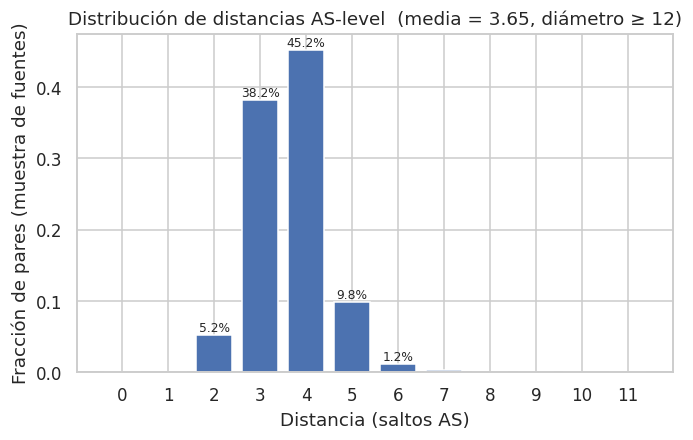

In [7]:
hops, counts = np.unique(dist_values.astype(int), return_counts=True)
frac = counts / counts.sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(hops, frac, color="#4C72B0", edgecolor="white")
for h, f in zip(hops, frac):
    if f > 0.005:
        ax.text(h, f + 0.005, f"{f:.1%}", ha="center", fontsize=8)
ax.set_xlabel("Distancia (saltos AS)")
ax.set_ylabel("Fracción de pares (muestra de fuentes)")
ax.set_title(f"Distribución de distancias AS-level  (media = {dist_values.mean():.2f}, diámetro ≥ {macro['diámetro GCC (>= cota doble barrido)']})")
ax.set_xticks(hops)
savefig("02_distancias")
plt.show()

**Interpretación.** La densidad $\sim 10^{-4}$ confirma un grafo extremadamente disperso, pero la
distancia media de pocos saltos evidencia el *small-world* característico de Internet: cualquier
par de ASes está a 3–4 saltos gracias a un núcleo de tránsito muy conectado. La cola de la
distribución (distancias $\geq 6$) corresponde a stubs regionales que sólo alcanzan el núcleo a través
de una cadena de proveedores de tránsito (jerarquía Tier-3 → Tier-2 → Tier-1). La razón
$\langle k^2\rangle/\langle k\rangle^2 \gg 1$ es la primera evidencia cuantitativa de heterogeneidad
de grado, que se analiza en detalle a continuación.

## 3. Distribución de grados y naturaleza *scale-free*

Faloutsos, Faloutsos & Faloutsos (SIGCOMM 1999) mostraron que el grado de los ASes sigue
$P(k) \propto k^{-\gamma}$ con $\gamma \approx 2.1$–$2.2$. Este análisis reproduce esa prueba con
tres herramientas complementarias:

1. **Visual**: $P(k)$ en escala log-log (cruda y con *binning* logarítmico para reducir el ruido de
   la cola) y la CCDF $P(K \geq k)$, cuya pendiente es $-(\gamma - 1)$ y no sufre el ruido del
   histograma.
2. **Ajuste por regresión log-log** (método clásico de Faloutsos): rápido pero sesgado; se reporta
   con $R^2$ sólo como referencia histórica.
3. **Ajuste MLE discreto con selección de $k_{\min}$ por Kolmogorov–Smirnov** (Clauset, Shalizi &
   Newman 2009): estimador consistente de $\gamma$ y comparación de verosimilitud contra una
   log-normal para decidir si la cola es realmente una ley de potencias.

In [8]:
k_vals, k_counts = np.unique(degree, return_counts=True)
pk = k_counts / N

# CCDF empírica P(K >= k)
ccdf = 1.0 - np.cumsum(pk) + pk

# Binning logarítmico de P(k)
bins = np.unique(np.floor(np.logspace(0, np.log10(degree.max()) + 0.05, 30)).astype(int))
hist, _ = np.histogram(degree, bins=bins)
widths = np.diff(bins)
pk_binned = hist / (N * widths)
bin_centers = np.sqrt(bins[:-1] * bins[1:])
mask_b = hist > 0

# Regresión log-log clásica sobre la CCDF (Faloutsos et al.)
lr = stats.linregress(np.log10(k_vals), np.log10(ccdf))
gamma_ols = 1 - lr.slope
print(f"Regresión log-log sobre CCDF: pendiente = {lr.slope:.3f}  ->  gamma_OLS = {gamma_ols:.3f}  (R² = {lr.rvalue**2:.3f})")

Regresión log-log sobre CCDF: pendiente = -1.058  ->  gamma_OLS = 2.058  (R² = 0.972)


### 3.1 Ajuste MLE discreto (Clauset–Shalizi–Newman)

Para una ley de potencias discreta $p(k) = k^{-\gamma} / \zeta(\gamma, k_{\min})$ el estimador de
máxima verosimilitud aproximado es
$\hat\gamma \simeq 1 + n \left[\sum_i \ln \frac{k_i}{k_{\min} - 1/2}\right]^{-1}$;
$k_{\min}$ se elige minimizando la distancia KS entre la CDF empírica y la ajustada. Se calcula
además el cociente de log-verosimilitud $\mathcal{R}$ frente a una log-normal en la misma cola
(prueba de Vuong): $\mathcal{R} > 0$ favorece la ley de potencias y el $p$-valor indica si la
diferencia es significativa. Advertencia metodológica: una log-normal truncada con $\mu \to -\infty$,
$\sigma \to \infty$ converge a una power-law, por lo que su MLE tiende a "escaparse" hacia ese
límite; los parámetros se acotan (como hace el paquete `powerlaw`) y, si $\mu$ queda en la cota, debe
leerse como "la log-normal sólo iguala a la power-law degenerándose en ella".

In [9]:
def fit_discrete_powerlaw(data, xmin_candidates=None, min_tail=50):
    data = np.asarray(data, dtype=float)
    if xmin_candidates is None:
        xmin_candidates = np.unique(data)
    best = None
    rows = []
    for xmin in xmin_candidates:
        tail = data[data >= xmin]
        n = tail.size
        if n < min_tail:
            break
        alpha = 1.0 + n / np.sum(np.log(tail / (xmin - 0.5)))
        # KS: CDF empírica vs CDF teórica discreta en los valores observados
        ks_x, ks_counts = np.unique(tail, return_counts=True)
        emp_cdf = np.cumsum(ks_counts) / n
        z_min = zeta(alpha, xmin)
        theo_ccdf = zeta(alpha, ks_x + 1) / z_min           # P(K > x)
        theo_cdf = 1.0 - theo_ccdf
        ks = np.max(np.abs(emp_cdf - theo_cdf))
        rows.append((xmin, alpha, n, ks))
        if best is None or ks < best["ks"]:
            best = {"xmin": xmin, "alpha": alpha, "n_tail": n, "ks": ks}
    return best, pd.DataFrame(rows, columns=["xmin", "alpha", "n_tail", "ks"])


def loglik_powerlaw(tail, alpha, xmin):
    return -alpha * np.sum(np.log(tail)) - tail.size * np.log(zeta(alpha, xmin))




def fit_truncated_lognormal(tail, xmin):
    # MLE de una log-normal truncada en [xmin - 1/2, inf): maximiza sum log f(x) - n log S(xmin - 1/2).
    # La verosimilitud truncada es degenerada (mu -> -inf, sigma -> inf imita una power-law), por lo que
    # se acotan los parámetros como hace el paquete `powerlaw`.
    from scipy.optimize import minimize
    logs = np.log(tail)
    lo = np.log(xmin - 0.5)

    def nll(theta):
        mu, sigma = theta
        ll = stats.norm.logpdf(logs, mu, sigma) - logs
        return -(ll.sum() - tail.size * stats.norm.logsf(lo, mu, sigma))

    x0 = np.array([logs.mean(), logs.std() + 1e-3])
    bounds = [(lo - 10.0, logs.max() + 2.0), (0.05, 5.0)]
    res = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)
    return float(res.x[0]), float(res.x[1])


def vuong_test(ll_pl_i, ll_alt_i):
    # Cociente de verosimilitud normalizado; p-valor bilateral (Vuong 1989 / Clauset 2009 ec. C.6).
    diff = ll_pl_i - ll_alt_i
    R = diff.sum()
    sd = diff.std(ddof=0) * np.sqrt(diff.size)
    p = math.erfc(abs(R) / (math.sqrt(2) * sd)) if sd > 0 else 1.0
    return R, p


# Sólo consideramos k_min hasta un valor razonable para no ajustar únicamente la cola extrema.
candidates = k_vals[(k_vals >= 1) & (k_vals <= 200)]
pl_fit, ks_table = fit_discrete_powerlaw(degree, candidates)
gamma_mle, kmin, n_tail, ks_d = pl_fit["alpha"], int(pl_fit["xmin"]), pl_fit["n_tail"], pl_fit["ks"]

tail = degree[degree >= kmin].astype(float)
ll_pl_i = -gamma_mle * np.log(tail) - np.log(zeta(gamma_mle, kmin))
mu_ln, sigma_ln = fit_truncated_lognormal(tail, kmin)
ll_ln_i = (stats.norm.logpdf(np.log(tail), mu_ln, sigma_ln) - np.log(tail)
           - stats.norm.logsf(np.log(kmin - 0.5), mu_ln, sigma_ln))
R_vuong, p_vuong = vuong_test(ll_pl_i, ll_ln_i)

# Error estándar de gamma (Clauset et al. ec. 3.2)
gamma_se = (gamma_mle - 1) / math.sqrt(n_tail)

fit_summary = pd.Series({
    "gamma (MLE discreto)": gamma_mle,
    "error estándar de gamma": gamma_se,
    "k_min óptimo (KS)": kmin,
    "nodos en la cola (k >= k_min)": n_tail,
    "fracción de nodos en la cola": n_tail / N,
    "distancia KS": ks_d,
    "gamma (regresión log-log CCDF)": gamma_ols,
    "log-verosimilitud power-law": ll_pl_i.sum(),
    "log-verosimilitud log-normal truncada": ll_ln_i.sum(),
    "log-normal: mu / sigma": f"{mu_ln:.2f} / {sigma_ln:.2f}",
    "R de Vuong (PL vs log-normal)": R_vuong,
    "p-valor de Vuong": p_vuong,
}, name="valor").to_frame()
display(fit_summary)

try:
    import powerlaw  # validación cruzada opcional
    pf = powerlaw.Fit(degree, discrete=True, verbose=False)
    R2, p2 = pf.distribution_compare("power_law", "lognormal")
    print(f"[powerlaw] alpha = {pf.power_law.alpha:.3f}, xmin = {pf.power_law.xmin:.0f}, R(PL vs LN) = {R2:.2f}, p = {p2:.3f}")
except ImportError:
    print("Paquete `powerlaw` no instalado; se omite la validación cruzada (pip install powerlaw).")

,valor
gamma (MLE discreto),2.12041
error estándar de gamma,0.0241353
k_min óptimo (KS),87
nodos en la cola (k >= k_min),2155
fracción de nodos en la cola,0.0245461
distancia KS,0.0436445
gamma (regresión log-log CCDF),2.05814
log-verosimilitud power-law,"-13,445"
log-verosimilitud log-normal truncada,"-13,450.4"
log-normal: mu / sigma,-5.54 / 3.24


Paquete `powerlaw` no instalado; se omite la validación cruzada (pip install powerlaw).


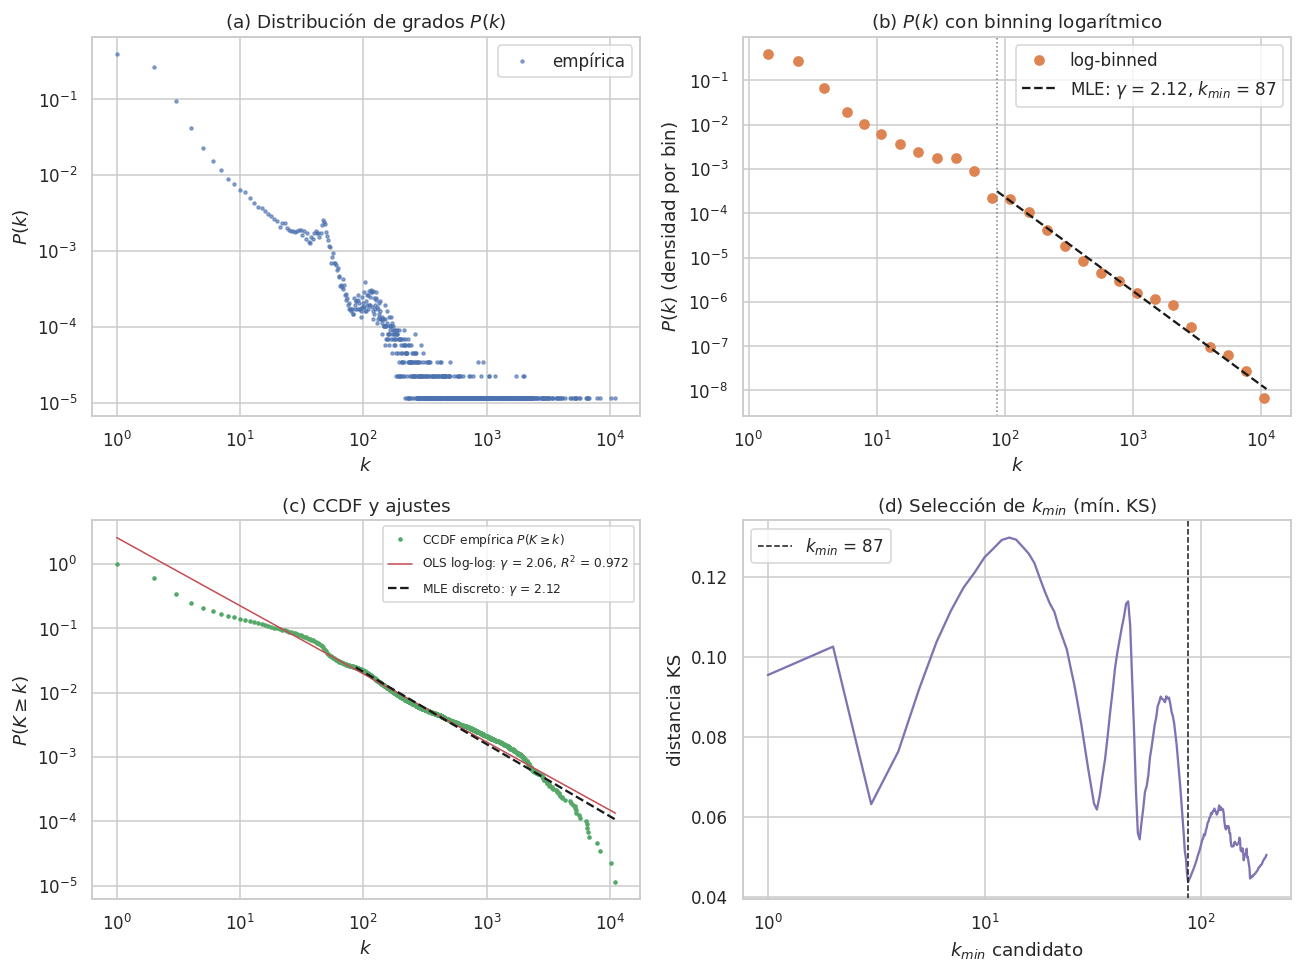

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) P(k) cruda
ax = axes[0, 0]
ax.loglog(k_vals, pk, ".", ms=4, alpha=0.6, color="#4C72B0", label="empírica")
ax.set_xlabel("$k$"); ax.set_ylabel("$P(k)$"); ax.set_title("(a) Distribución de grados $P(k)$")
ax.legend()

# (b) P(k) con binning logarítmico + recta MLE
ax = axes[0, 1]
ax.loglog(bin_centers[mask_b], pk_binned[mask_b], "o", color="#DD8452", label="log-binned")
kk = np.logspace(np.log10(kmin), np.log10(degree.max()), 50)
C = (n_tail / N) / zeta(gamma_mle, kmin)          # normalización de la cola
ax.loglog(kk, C * kk ** (-gamma_mle), "k--", label=fr"MLE: $\gamma$ = {gamma_mle:.2f}, $k_{{min}}$ = {kmin}")
ax.axvline(kmin, color="grey", ls=":", lw=1)
ax.set_xlabel("$k$"); ax.set_ylabel("$P(k)$ (densidad por bin)"); ax.set_title("(b) $P(k)$ con binning logarítmico")
ax.legend()

# (c) CCDF con ambos ajustes
ax = axes[1, 0]
ax.loglog(k_vals, ccdf, ".", ms=4, color="#55A868", label="CCDF empírica $P(K \\geq k)$")
kk_all = np.logspace(0, np.log10(degree.max()), 50)
ax.loglog(kk_all, 10 ** lr.intercept * kk_all ** lr.slope, "-", color="#C44E52", lw=1,
          label=fr"OLS log-log: $\gamma$ = {gamma_ols:.2f}, $R^2$ = {lr.rvalue**2:.3f}")
ccdf_kmin = ccdf[np.searchsorted(k_vals, kmin)]
ax.loglog(kk, ccdf_kmin * (zeta(gamma_mle, kk) / zeta(gamma_mle, kmin)), "k--",
          label=fr"MLE discreto: $\gamma$ = {gamma_mle:.2f}")
ax.set_xlabel("$k$"); ax.set_ylabel("$P(K \\geq k)$"); ax.set_title("(c) CCDF y ajustes")
ax.legend(fontsize=8)

# (d) distancia KS vs k_min
ax = axes[1, 1]
ax.semilogx(ks_table.xmin, ks_table.ks, "-", color="#8172B2")
ax.axvline(kmin, color="k", ls="--", lw=1, label=f"$k_{{min}}$ = {kmin}")
ax.set_xlabel("$k_{min}$ candidato"); ax.set_ylabel("distancia KS"); ax.set_title("(d) Selección de $k_{min}$ (mín. KS)")
ax.legend()

plt.tight_layout()
savefig("03_distribucion_grados")
plt.show()

**Interpretación.**

- La CCDF es aproximadamente lineal en log-log durante 2–3 décadas: la distribución es de cola
  pesada. El exponente MLE $\hat\gamma$ suele situarse en $2.0$–$2.3$, coherente con Faloutsos et
  al. (1999) y con las mediciones posteriores de CAIDA. Un $\gamma < 3$ implica varianza divergente
  de grado (hubs cuya conectividad crece con el tamaño de la red) y explica la robustez a fallas
  aleatorias / fragilidad ante ataques dirigidos de la topología BGP.
- La regresión OLS subestima o sobreestima $\gamma$ según la porción de cola incluida; el MLE con
  $k_{\min}$ seleccionado por KS es el valor a reportar.
- La comparación con la log-normal truncada (Vuong) es la prueba formal: $\mathcal{R} > 0$ con
  $p$ pequeño favorece la power-law; $p > 0.1$ significa que la cola es compatible con ambas
  alternativas de cola pesada, resultado frecuente en grafos AS-level. Lea el valor obtenido arriba
  antes de afirmar "scale-free" en sentido estricto. En cualquier caso: la parte alta del grado está dominada por *route servers* de IXPs y grandes
  proveedores con miles de peers visibles, mientras que la periferia ($k \le 2$) es masiva porque la
  mayoría de los ASes son stubs single- o dual-homed. La conclusión de ingeniería es la misma:
  **la conectividad está extremadamente concentrada**, lo que justifica muestrear vecindarios en los
  loaders de la GNN (los hubs saturan cualquier agregación full-batch).

## 4. Centralidades e inferencia del núcleo BGP (Tier-1 / tránsito)

Cada medida captura un rol distinto en el plano de control:

| Medida | Qué mide en BGP | Rol que destaca |
|---|---|---|
| Grado ($k$) | Número de vecinos eBGP visibles | Grandes proveedores de tránsito y route servers / peering masivo (HE, IXPs) |
| Fuerza ($s$ = Σ `weight`) | Volumen de paths que atraviesan sus adyacencias | Backbones Tier-1 por los que "pasa" la tabla global |
| Intermediación (betweenness) | Fracción de caminos más cortos que cruzan el AS | Puentes de tránsito: quien conecta regiones o clientes al núcleo |
| PageRank | Probabilidad estacionaria de un paseo aleatorio | ASes conectados a otros ASes importantes |
| Eigenvector | Igual que PageRank pero sin teletransporte | Miembros del núcleo densamente interconectado |
| Closeness / harmónica | Inverso de la distancia media al resto | Proximidad global; exacta sólo para los candidatos al Top |

La intermediación exacta es $\mathcal{O}(|V|\cdot|E|)$; se usa el **estimador de Brandes–Pich con
muestreo de fuentes** (`k = BETWEENNESS_SAMPLES`) paralelizado por procesos. Los caminos más cortos
del grafo no coinciden con las rutas BGP reales (que obedecen políticas valley-free), por lo que la
intermediación debe leerse como *potencial estructural de tránsito*, no como tráfico.

In [11]:
# --- grado, fuerza -----------------------------------------------------------------
cent = pd.DataFrame(index=pd.Index(NODES, name="asn"))
cent["grado"] = degree
cent["grado_norm"] = degree / (N - 1)
cent["fuerza"] = strength

# --- PageRank (scipy, potencia) y eigenvector (ARPACK) -------------------------------
t0 = time.perf_counter()
pr = nx.pagerank(G, alpha=0.85, weight=None, tol=1e-8)
cent["pagerank"] = pd.Series(pr)
print(f"PageRank en {time.perf_counter() - t0:.1f} s")

t0 = time.perf_counter()
ev = nx.eigenvector_centrality_numpy(Gcc, weight=None)
cent["eigenvector"] = pd.Series(ev)
print(f"Eigenvector en {time.perf_counter() - t0:.1f} s")

PageRank en 1.6 s


Eigenvector en 1.8 s


In [12]:
# --- intermediación aproximada, paralela por muestreo de fuentes ----------------------
def _betweenness_chunk(args):
    k, seed = args
    return nx.betweenness_centrality(Gcc, k=k, normalized=True, weight=None, seed=seed)


def approx_betweenness(samples, workers):
    per_worker = max(1, samples // workers)
    jobs = [(per_worker, RANDOM_SEED + i) for i in range(workers)]
    if workers == 1:
        return _betweenness_chunk((samples, RANDOM_SEED))
    try:
        import multiprocessing as mp
        ctx = mp.get_context("fork")    # Gcc se hereda por copy-on-write sin serializar
        with ProcessPoolExecutor(max_workers=workers, mp_context=ctx) as pool:
            partials = list(pool.map(_betweenness_chunk, jobs))
    except Exception as exc:        # p. ej. sin fork (Windows) -> fallback serial
        print(f"Paralelismo no disponible ({exc!r}); se ejecuta en serie.")
        return _betweenness_chunk((samples, RANDOM_SEED))
    acc = {}
    for part in partials:
        for node, val in part.items():
            acc[node] = acc.get(node, 0.0) + val / len(partials)
    return acc


t0 = time.perf_counter()
bc = approx_betweenness(BETWEENNESS_SAMPLES, N_WORKERS)
cent["betweenness"] = pd.Series(bc)
cent["betweenness"] = cent["betweenness"].fillna(0.0)
print(f"Betweenness aproximada ({BETWEENNESS_SAMPLES} fuentes, {N_WORKERS} procesos) en {time.perf_counter() - t0:.1f} s")

Betweenness aproximada (256 fuentes, 4 procesos) en 60.9 s


### 4.1 Ranking compuesto y Top 15

Cada AS recibe un rango por medida; el **puntaje compuesto** promedia rangos (conteo de Borda) por
**familia** — conectividad local (grado, PageRank, eigenvector, muy correlacionadas entre sí), volumen
de paths (fuerza) y posición en caminos (intermediación) — con peso 1/3 cada una, para que los hubs de
peering abierto no dominen sólo por tener tres medidas de grado a su favor. Para los 40 mejores candidatos se calcula
además la **closeness exacta** (BFS en C desde cada uno), que sería prohibitiva para toda la red.
La interpretación del rol combina el ranking con conocimiento de dominio (lista de Tier-1
reconocidos del *transit-free club* y de operadores con perfiles de peering masivo).

In [13]:
# Nombres de ASNs bien conocidos (referencia de dominio; no afecta las métricas).
AS_NAMES = {
    174: "Cogent", 209: "Lumen (CenturyLink/Qwest)", 286: "KPN", 701: "Verizon", 1239: "Cogent (ex Sprint)",
    1273: "Vodafone", 1299: "Arelion (Telia)", 2914: "NTT", 3257: "GTT", 3320: "Deutsche Telekom",
    3356: "Lumen (Level3)", 3491: "PCCW Global", 5511: "Orange", 6453: "Tata Communications",
    6461: "Zayo", 6762: "Telecom Italia Sparkle", 6830: "Liberty Global", 7018: "AT&T", 12956: "Telxius",
    6939: "Hurricane Electric", 24482: "SG.GS", 49544: "i3D.net", 36236: "NetActuate", 137409: "GSL Networks",
    20473: "Vultr / Constant", 13335: "Cloudflare", 15169: "Google", 16509: "Amazon", 32934: "Meta",
    8075: "Microsoft", 9002: "RETN", 4637: "Telstra Global", 7922: "Comcast", 3216: "Vimpelcom",
    12389: "Rostelecom", 9498: "Bharti Airtel", 4134: "China Telecom", 4809: "China Telecom (CN2)",
    58453: "China Mobile Intl", 9304: "HGC", 4826: "Vocus", 3303: "Swisscom", 2497: "IIJ", 7473: "Singtel",
    6057: "Movistar Chile", 27651: "Entel Chile", 22047: "VTR", 7004: "Claro Chile", 14259: "GTD",
    9009: "M247", 34927: "iFog", 35280: "Colt (ACORUS)", 8220: "Colt",
    31133: "MegaFon", 20485: "TransTeleCom", 60068: "CDN77", 199524: "G-Core", 39120: "Convergenze",
    16276: "OVH", 12876: "Scaleway", 20940: "Akamai", 3223: "Voxility", 6777: "AMS-IX RS",
    8714: "LINX RS", 6695: "DE-CIX RS", 42: "WoodyNet / PCH", 3856: "PCH", 4181: "TDS", 6327: "Shaw",
    577: "Bell Canada", 812: "Rogers", 7545: "TPG", 4739: "Internode", 2516: "KDDI", 4713: "NTT OCN",
    17676: "SoftBank", 9318: "SK Broadband", 4766: "KT", 3786: "LG Uplus", 4788: "TM Malaysia",
    17451: "Biznet", 7713: "Telkom Indonesia", 4761: "Indosat", 38040: "TOT", 4651: "CAT Telecom",
    7643: "VNPT", 18403: "FPT", 45899: "VNPT-AS", 9299: "PLDT", 4775: "Globe", 132203: "Tencent",
    45102: "Alibaba", 37100: "SEACOM", 36351: "IBM Cloud", 33891: "Core-Backbone", 5400: "BT",
    2856: "BT UK", 3292: "TDC", 1257: "Tele2", 3301: "Telia Sweden", 8359: "MTS", 8551: "Bezeq",
    12322: "Free", 5410: "Bouygues", 15557: "SFR", 3269: "Telecom Italia", 12874: "Fastweb",
    3352: "Telefónica España", 12479: "Orange España", 6739: "Vodafone ONO", 2860: "NOS", 3243: "MEO",
    8708: "RCS&RDS", 6849: "Ukrtelecom", 21219: "Datagroup", 25152: "RIPE K-root", 6447: "Route Views",
    3130: "RGnet", 7660: "APAN", 11537: "Internet2", 20965: "GÉANT", 786: "Jisc", 680: "DFN",
    2200: "RENATER", 137: "GARR", 766: "RedIRIS", 1916: "RNP", 27750: "REUNA", 11164: "Cogent (ex Sprint)",
    28329: "Vivo/Telefónica Brasil", 26615: "TIM Brasil", 4230: "Claro Brasil (Embratel)", 8167: "Oi",
    7303: "Telecom Argentina", 10318: "Telecom Argentina (Personal)", 22927: "Telefónica Argentina",
    19429: "Claro Colombia", 3816: "Colombia Telecomunicaciones", 8151: "Telmex México", 6503: "Axtel",
    11172: "Alestra", 264409: "IX.br", 262589: "IX.br", 61568: "IX.br RS", 26162: "IX.br", 52320: "GlobeNet",
    23520: "Columbus Networks", 32590: "Valve", 14840: "BR.Digital (Commcorp)", 7195: "EDGEUNO",
    14537: "Continent 8", 51185: "Onecom", 16552: "Tiggee (DNS Made Easy)", 24940: "Hetzner", 39351: "31173 Services",
    41327: "Fiber Telecom", 53062: "GGNET", 271253: "Link Brasil", 264409: "IX.br", 57463: "NetIX", 37468: "Angola Cables", 27947: "Telconet", 14080: "Telmex Colombia", 6147: "Telefónica del Perú",
    12252: "América Móvil Perú", 61832: "SIX (Perú)", 53013: "W I X", 28398: "ITX", 262206: "NAP Colombia",
}
TIER1 = {174, 209, 286, 701, 1239, 1273, 1299, 2914, 3257, 3320, 3356, 3491, 5511, 6453, 6461, 6762, 6830, 7018, 12956}
PEERING_HUBS = {6939, 24482, 49544, 36236, 137409, 20473, 13335, 15169, 16509, 32934, 8075, 20940, 199524, 32590, 60068, 16276}

metrics = ["grado", "fuerza", "betweenness", "pagerank", "eigenvector"]
for m in metrics:
    cent[f"rank_{m}"] = cent[m].rank(ascending=False, method="min").astype(int)
# Familias: conectividad local (grado, PageRank, eigenvector están fuertemente correlacionadas),
# volumen de paths (fuerza) y posición en caminos (intermediación). Cada familia pesa 1/3.
cent["rank_conectividad"] = cent[["rank_grado", "rank_pagerank", "rank_eigenvector"]].mean(axis=1)
cent["rank_compuesto"] = cent[["rank_conectividad", "rank_fuerza", "rank_betweenness"]].mean(axis=1)
cent = cent.sort_values("rank_compuesto")

# Closeness / harmónica exacta sólo para los 40 mejores candidatos (BFS en C).
top_candidates = cent.index[:40]
idx_top = np.array([NODE_INDEX[a] for a in top_candidates])
D_top = csgraph.shortest_path(A, method="D", directed=False, unweighted=True, indices=idx_top)
D_top = D_top[:, gcc_idx]
closeness_exact = (D_top.shape[1] - 1) / D_top.sum(axis=1)
harmonic_exact = np.where(D_top > 0, 1.0 / D_top, 0.0).sum(axis=1)
cent.loc[top_candidates, "closeness"] = closeness_exact
cent.loc[top_candidates, "harmonica"] = harmonic_exact


def infer_role(row):
    asn = row.name
    if asn in TIER1:
        return "Tier-1 (transit-free)"
    if asn in PEERING_HUBS:
        return "Hub de peering masivo / hyper-giant"
    rb, rd, rs = row["rank_betweenness"], row["rank_grado"], row["rank_fuerza"]
    if rs <= 20 and rb <= 20:
        return "Backbone de tránsito global"
    if rd <= 20 and rb > 50:
        return "Peering masivo (IXP / route server)"
    if rb <= 30 and rd > 100:
        return "Puente de tránsito regional"
    if rd <= 50 or rb <= 50:
        return "Proveedor de tránsito Tier-2"
    return "Tránsito / peering relevante"


top15 = cent.head(15).copy()
top15.insert(0, "nombre", [AS_NAMES.get(a, "—") for a in top15.index])
top15["rol inferido"] = top15.apply(infer_role, axis=1)
cols = ["nombre", "grado", "fuerza", "betweenness", "pagerank", "eigenvector", "closeness",
        "rank_grado", "rank_fuerza", "rank_betweenness", "rank_pagerank", "rank_eigenvector", "rank_compuesto", "rol inferido"]
top15_view = top15[cols].rename(columns={"fuerza": "fuerza (Σ weight)"})
display(top15_view.style.format({
    "fuerza (Σ weight)": "{:,.0f}", "betweenness": "{:.4f}", "pagerank": "{:.2e}",
    "eigenvector": "{:.3f}", "closeness": "{:.3f}", "rank_compuesto": "{:.1f}"}).background_gradient(
    subset=["rank_grado", "rank_fuerza", "rank_betweenness", "rank_pagerank", "rank_eigenvector"], cmap="Blues_r"))
top15_view.to_csv(FIG_DIR / "04_top15_centralidad.csv")

,nombre,grado,fuerza (Σ weight),betweenness,pagerank,eigenvector,closeness,rank_grado,rank_fuerza,rank_betweenness,rank_pagerank,rank_eigenvector,rank_compuesto,rol inferido
asn,,,,,,,,,,,,,,
6939,Hurricane Electric,11090,"259,192,749",0.1754,6.87e-03,0.108,0.485,1,1,1,4,2,1.4,Hub de peering masivo / hyper-giant
24482,SG.GS,10196,"19,166,312",0.0560,5.36e-03,0.110,0.449,2,24,5,5,1,10.6,Hub de peering masivo / hyper-giant
49544,i3D.net,8332,"25,881,555",0.0275,4.09e-03,0.102,0.454,3,19,9,7,3,10.8,Hub de peering masivo / hyper-giant
199524,G-Core,5752,"29,414,270",0.0199,2.66e-03,0.087,0.443,10,17,12,13,14,13.8,Hub de peering masivo / hyper-giant
137409,GSL Networks,6716,"18,511,759",0.0183,3.17e-03,0.098,0.445,5,27,13,11,5,15.7,Hub de peering masivo / hyper-giant
174,Cogent,6576,"191,015,457",0.0764,7.75e-03,0.040,0.417,7,4,4,3,121,17.2,Tier-1 (transit-free)
9498,Bharti Airtel,3699,"45,441,113",0.0235,2.45e-03,0.057,0.422,26,14,11,14,58,19.2,Backbone de tránsito global
3356,Lumen (Level3),6590,"230,369,795",0.1035,8.99e-03,0.034,0.430,6,3,2,2,157,20.0,Tier-1 (transit-free)
32590,Valve,6414,"13,553,820",0.0179,2.86e-03,0.089,0.446,9,40,14,12,10,21.4,Hub de peering masivo / hyper-giant


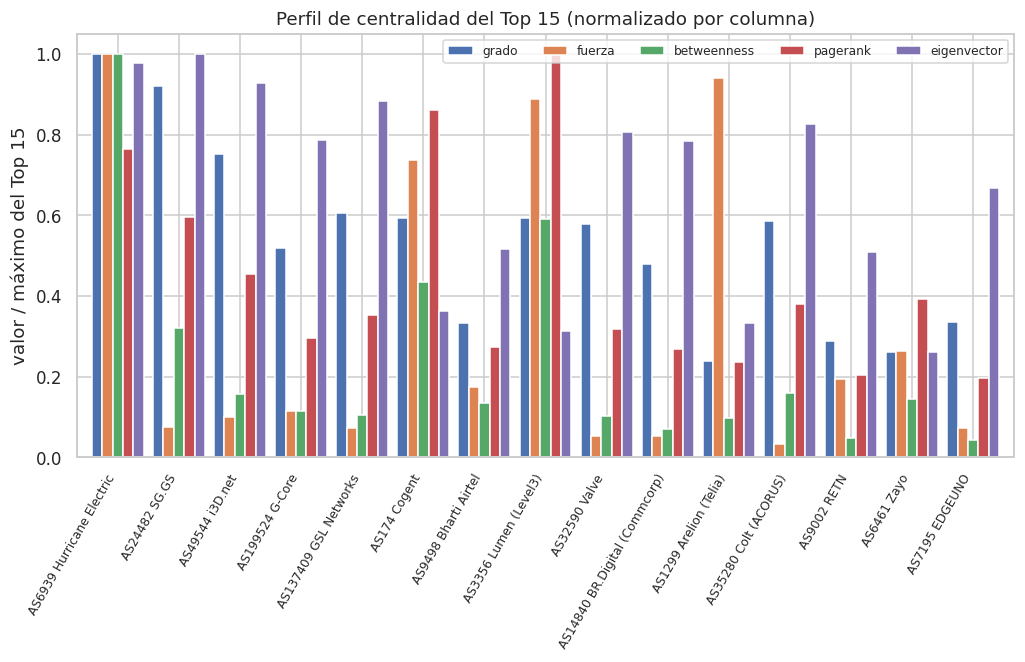

In [14]:
# Perfil normalizado de los 15 ASes más influyentes según cada medida.
prof = top15[metrics].copy()
prof = prof / prof.max()
prof.index = [f"AS{a} {AS_NAMES.get(a, '')}".strip() for a in prof.index]

fig, ax = plt.subplots(figsize=(11, 5))
prof.plot(kind="bar", ax=ax, width=0.85, edgecolor="white")
ax.set_ylabel("valor / máximo del Top 15")
ax.set_title("Perfil de centralidad del Top 15 (normalizado por columna)")
ax.legend(ncol=5, fontsize=8, loc="upper right")
plt.xticks(rotation=60, ha="right", fontsize=8)
savefig("04_top15_perfil")
plt.show()

### 4.2 Matriz de centralidad (correlación de Spearman)

La correlación de rangos entre medidas revela cuánta información redundante aportan. Se espera
grado ≈ PageRank ≈ eigenvector (todas miden conectividad local o local-ponderada) y una correlación
menor con la intermediación, que responde a la posición en los caminos entre regiones.

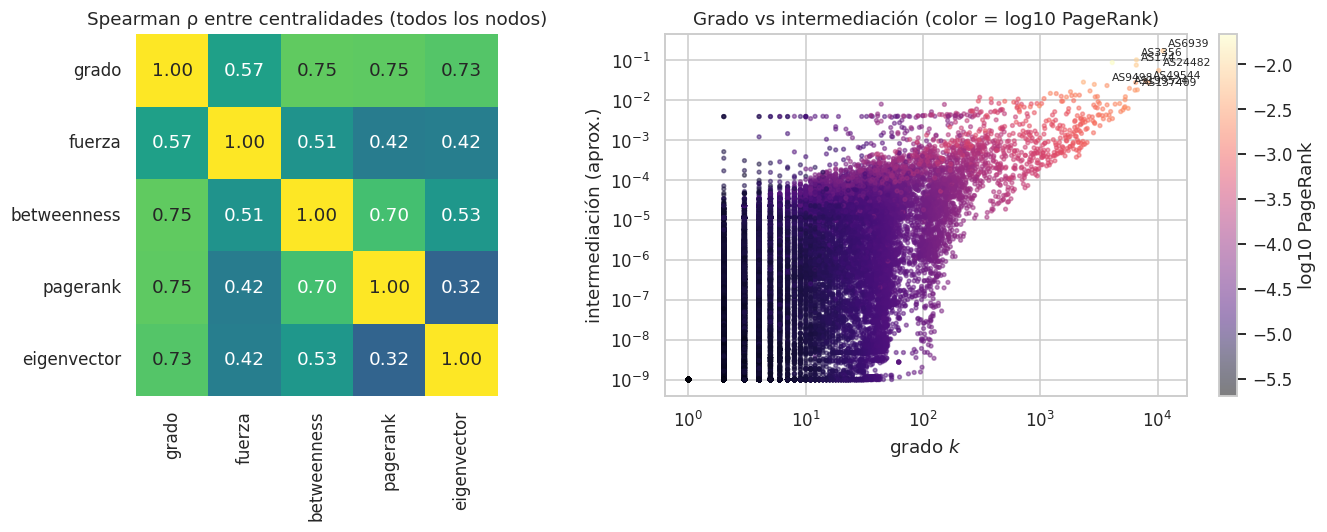

In [15]:
corr_cols = ["grado", "fuerza", "betweenness", "pagerank", "eigenvector"]
corr = cent[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.25]})
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, square=True, ax=axes[0], cbar=False)
axes[0].set_title("Spearman ρ entre centralidades (todos los nodos)")

ax = axes[1]
sc = ax.scatter(cent["grado"], cent["betweenness"] + 1e-9, c=np.log10(cent["pagerank"]), s=6, alpha=0.5, cmap="magma")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("grado $k$"); ax.set_ylabel("intermediación (aprox.)")
ax.set_title("Grado vs intermediación (color = log10 PageRank)")
for asn in top15.index[:8]:
    ax.annotate(f"AS{asn}", (cent.at[asn, "grado"], cent.at[asn, "betweenness"] + 1e-9), fontsize=7, xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc, ax=ax, label="log10 PageRank")
plt.tight_layout()
savefig("04_matriz_centralidad")
plt.show()

**Interpretación del Top 15.** En los snapshots recientes de Route Views + RIS aparecen sistemáticamente
tres perfiles:

1. **Backbones Tier-1** (Lumen 3356, Cogent 174, Arelion 1299, NTT 2914, GTT 3257, Tata 6453, Telxius
   12956…): fuerza e intermediación muy altas — sus adyacencias soportan un enorme volumen de paths —
   con grado moderado (miles de clientes, pero no decenas de miles de peers).
2. **Hubs de peering abierto** (Hurricane Electric 6939, SG.GS 24482, i3D 49544, NetActuate 36236,
   GSL 137409): grado altísimo por política de *open peering* en cientos de IXPs, pero fuerza e
   intermediación menores porque los paths que revelan son en gran parte de peering lateral con stubs.
   Son también los ASes que más sesgan a un modelo GNN full-batch.
3. **Grandes proveedores regionales / hyper-giants** que actúan como puentes hacia continentes
   específicos (p. ej. Telstra 4637, PCCW 3491, China Telecom 4134, IX.br, HGC 9304).

El desacople entre grado e intermediación (puntos por debajo de la diagonal en el scatter) identifica
route servers e IXPs: muchos vecinos pero casi ningún camino más corto pasa "a través" de ellos
porque sus vecinos también se conectan directamente al núcleo. Las bandas horizontales en la parte
baja del scatter son el artefacto de discretización del estimador muestreado (un nodo atravesado por
los caminos de una sola fuente muestreada recibe un valor cuantizado $\propto 1/k$); no afectan al Top.

## 5. Agrupamiento, asortatividad y descomposición $k$-core

- **Clustering**: la transitividad global $C = 3\,\triangle / \text{tripletes}$ y el clustering local
  promedio $\bar{C}$ (Watts–Strogatz). En Internet $\bar{C} \gg C$: los stubs de bajo grado están
  conectados a proveedores que a su vez peerean entre sí (triángulos cliente-proveedor-proveedor),
  mientras que los hubs tienen vecindarios enormes y poco densos. La curva $C(k) \sim k^{-1}$ es la
  firma de una organización **jerárquica** (Ravasz & Barabási 2003).
- **Asortatividad de grado** $r$ (Newman 2002): Internet es **disasortativa** ($r \approx -0.2$):
  los ASes de bajo grado se conectan preferentemente a hubs (clientes → proveedores de tránsito) y
  los hubs se conectan con muchos stubs. La curva $k_{nn}(k)$ decreciente lo confirma.
- **$k$-core**: el $k$-core es el subgrafo maximal en que todo nodo tiene grado $\geq k$ dentro del
  subgrafo. La *coreness* máxima aísla el núcleo ("nucleus" en el modelo *medusa* de Carmi et al. 2007):
  un conjunto pequeño y casi completamente interconectado de Tier-1, grandes Tier-2 e hyper-giants.

In [16]:
# --- clustering: triángulos una sola vez, luego derivamos local y global ------------
t0 = time.perf_counter()
tri = nx.triangles(G)
tri_arr = np.array([tri[n] for n in NODES], dtype=float)
kk2 = degree * (degree - 1) / 2.0
local_c = np.divide(tri_arr, kk2, out=np.zeros_like(tri_arr), where=kk2 > 0)
print(f"Triángulos en {time.perf_counter() - t0:.1f} s")

clustering = {}
clustering["triángulos totales"] = int(tri_arr.sum() / 3)
clustering["transitividad global C"] = float(tri_arr.sum() / kk2.sum())
clustering["clustering local promedio (todos, k<2 -> 0)"] = float(local_c.mean())
clustering["clustering local promedio (k >= 2)"] = float(local_c[degree >= 2].mean())
clustering["fracción de nodos con C_i = 0"] = float(np.mean(local_c == 0))

# --- asortatividad --------------------------------------------------------------------
t0 = time.perf_counter()
r_deg = nx.degree_pearson_correlation_coefficient(G)
clustering["asortatividad de grado r (Pearson)"] = float(r_deg)
knn = nx.average_degree_connectivity(G)             # k -> <k_nn>(k)
print(f"Asortatividad en {time.perf_counter() - t0:.1f} s")

# --- k-core ---------------------------------------------------------------------------
t0 = time.perf_counter()
core_number = nx.core_number(G)
core_arr = np.array([core_number[n] for n in NODES])
k_max = int(core_arr.max())
cent["coreness"] = pd.Series(core_number)
clustering["coreness máxima k_max"] = k_max
clustering["nodos en el k_max-core"] = int((core_arr == k_max).sum())
clustering["nodos en la 1-shell (periferia pura)"] = int((core_arr == 1).sum())
clustering["nodos con coreness <= 2"] = int((core_arr <= 2).sum())
print(f"k-core en {time.perf_counter() - t0:.1f} s")

clustering_df = pd.Series(clustering, name="valor").to_frame()
display(clustering_df)

Triángulos en 5.0 s


Asortatividad en 3.4 s


k-core en 8.9 s


,valor
triángulos totales,1.7841e+07
transitividad global C,0.062962
"clustering local promedio (todos, k<2 -> 0)",0.29771
clustering local promedio (k >= 2),0.490149
fracción de nodos con C_i = 0,0.582033
asortatividad de grado r (Pearson),-0.29058
coreness máxima k_max,182
nodos en el k_max-core,316
nodos en la 1-shell (periferia pura),"34,942"
nodos con coreness <= 2,"59,590"


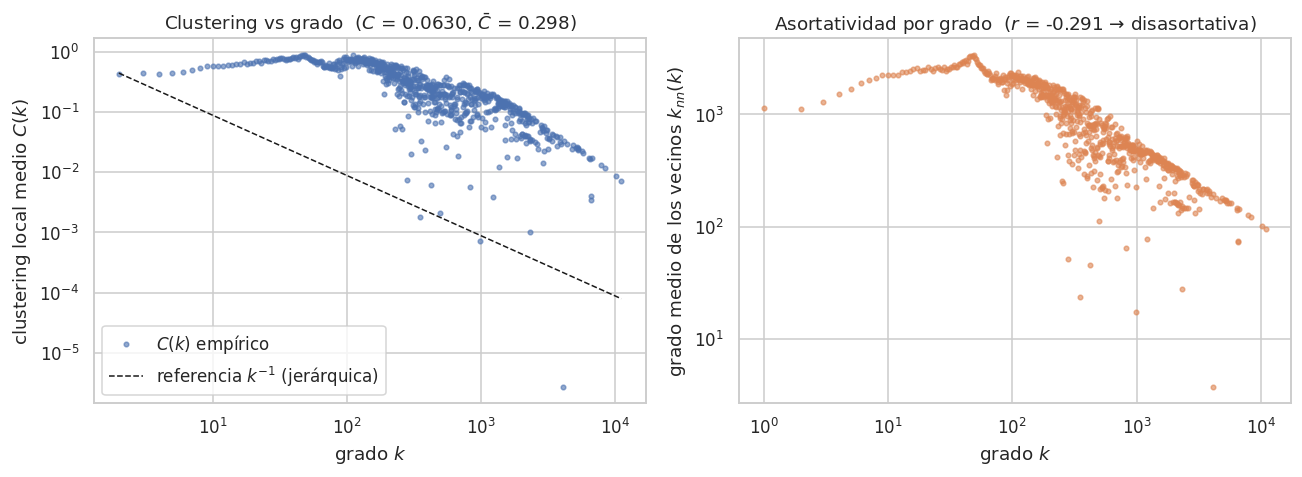

In [17]:
# C(k) y k_nn(k) promediados por grado
ck = pd.DataFrame({"k": degree, "C": local_c}).groupby("k")["C"].mean()
ck = ck[ck.index >= 2]
knn_s = pd.Series(knn).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.loglog(ck.index, ck.values, ".", alpha=0.6, color="#4C72B0", label="$C(k)$ empírico")
kk = np.logspace(np.log10(2), np.log10(degree.max()), 20)
ax.loglog(kk, ck.iloc[:5].mean() * (kk / 2) ** -1, "k--", lw=1, label="referencia $k^{-1}$ (jerárquica)")
ax.set_xlabel("grado $k$"); ax.set_ylabel("clustering local medio $C(k)$")
ax.set_title(f"Clustering vs grado  ($C$ = {clustering['transitividad global C']:.4f}, $\\bar{{C}}$ = {clustering['clustering local promedio (todos, k<2 -> 0)']:.3f})")
ax.legend()

ax = axes[1]
ax.loglog(knn_s.index, knn_s.values, ".", alpha=0.6, color="#DD8452")
ax.set_xlabel("grado $k$"); ax.set_ylabel("grado medio de los vecinos $k_{nn}(k)$")
ax.set_title(f"Asortatividad por grado  ($r$ = {r_deg:.3f} → {'disasortativa' if r_deg < 0 else 'asortativa'})")
plt.tight_layout()
savefig("05_clustering_asortatividad")
plt.show()

### 5.1 Estructura de capas ($k$-shells)

La descomposición asigna a cada AS su *coreness*. Analizamos el tamaño de cada shell, la densidad
interna de cada $k$-core y la composición del núcleo máximo.

,nodos,aristas,densidad,grado medio interno
k,,,,
78,1838,229781,0.13611,250.034
88,1722,220181,0.148592,255.727
99,1584,207244,0.165301,261.672
112,1308,178238,0.20852,272.535
126,1024,144699,0.276261,282.615
142,761,109647,0.379165,288.166
161,534,75254,0.5288,281.85
182,316,38550,0.774563,243.987


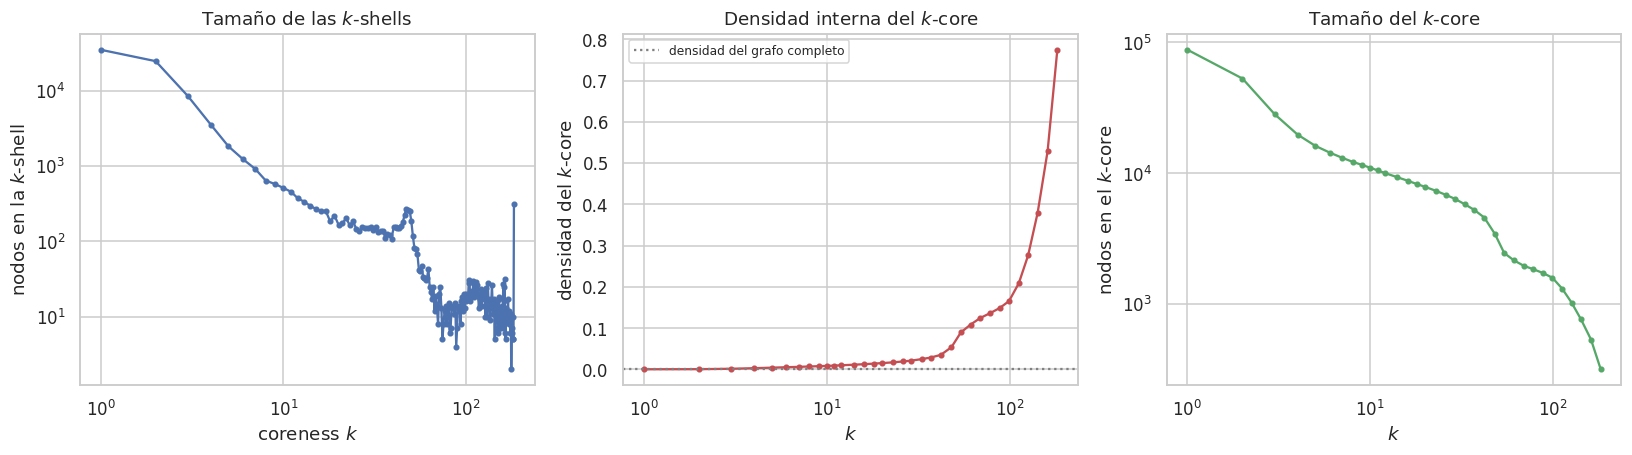

In [18]:
shell_sizes = pd.Series(core_arr).value_counts().sort_index()
shell_sizes.name = "nodos"

# Densidad interna y tamaño del k-core para un barrido de k (usando la coreness ya calculada).
ks = np.unique(np.concatenate([np.arange(1, min(k_max, 10) + 1), np.unique(np.geomspace(10, k_max, 25).astype(int)), [k_max]]))
core_rows = []
for k in ks:
    members = NODES[core_arr >= k]
    sel = np.where(core_arr >= k)[0]
    sub = A[sel][:, sel]
    n_k, m_k = len(members), int(sub.nnz // 2)
    core_rows.append({"k": int(k), "nodos": n_k, "aristas": m_k, "densidad": m_k / (n_k * (n_k - 1) / 2) if n_k > 1 else np.nan,
                      "grado medio interno": 2 * m_k / n_k if n_k else np.nan})
core_df = pd.DataFrame(core_rows).set_index("k")
display(core_df.tail(8))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].loglog(shell_sizes.index, shell_sizes.values, "o-", ms=3, color="#4C72B0")
axes[0].set_xlabel("coreness $k$"); axes[0].set_ylabel("nodos en la $k$-shell"); axes[0].set_title("Tamaño de las $k$-shells")

axes[1].semilogx(core_df.index, core_df["densidad"], "o-", ms=3, color="#C44E52")
axes[1].set_xlabel("$k$"); axes[1].set_ylabel("densidad del $k$-core"); axes[1].set_title("Densidad interna del $k$-core")
axes[1].axhline(nx.density(G), color="grey", ls=":", label="densidad del grafo completo"); axes[1].legend(fontsize=8)

axes[2].loglog(core_df.index, core_df["nodos"], "o-", ms=3, color="#55A868")
axes[2].set_xlabel("$k$"); axes[2].set_ylabel("nodos en el $k$-core"); axes[2].set_title("Tamaño del $k$-core")
plt.tight_layout()
savefig("05_kcore_shells")
plt.show()

In [19]:
# Composición del núcleo k_max
core_nodes = NODES[core_arr == k_max]
K = G.subgraph(core_nodes).copy()
core_table = cent.loc[core_nodes, ["grado", "fuerza", "betweenness", "pagerank", "rank_compuesto"]].copy()
core_table.insert(0, "nombre", [AS_NAMES.get(a, "—") for a in core_table.index])
core_table["grado interno"] = pd.Series(dict(K.degree()))
core_table["Tier-1"] = core_table.index.isin(TIER1)
core_table = core_table.sort_values("rank_compuesto")

print(f"k_max = {k_max}: núcleo con {K.number_of_nodes()} ASes y {K.number_of_edges()} aristas, "
      f"densidad interna = {nx.density(K):.3f}, diámetro interno = {nx.diameter(K) if nx.is_connected(K) else 'n/c'}")
print(f"Tier-1 reconocidos dentro del núcleo: {sorted(set(core_nodes) & TIER1)}")
print(f"Tier-1 reconocidos fuera del núcleo: {sorted(TIER1 - set(core_nodes))} "
      f"(coreness: {[core_number.get(a) for a in sorted(TIER1 - set(core_nodes))]})")
display(core_table.head(25).style.format({"fuerza": "{:,.0f}", "betweenness": "{:.4f}", "pagerank": "{:.2e}", "rank_compuesto": "{:.1f}"}))
core_table.to_csv(FIG_DIR / "05_kmax_core.csv")

k_max = 182: núcleo con 316 ASes y 38550 aristas, densidad interna = 0.775, diámetro interno = 2
Tier-1 reconocidos dentro del núcleo: [1299, 3356, 6461]
Tier-1 reconocidos fuera del núcleo: [174, 209, 286, 701, 1239, 1273, 2914, 3257, 3320, 3491, 5511, 6453, 6762, 6830, 7018, 12956] (coreness: [180, 15, 159, 64, 4, 110, 172, 162, 147, 158, 138, 162, 162, 136, 56, 113])


,nombre,grado,fuerza,betweenness,pagerank,rank_compuesto,grado interno,Tier-1
asn,,,,,,,,
6939,Hurricane Electric,11090,"259,192,749",0.1754,6.87e-03,1.4,312,False
24482,SG.GS,10196,"19,166,312",0.0560,5.36e-03,10.6,312,False
49544,i3D.net,8332,"25,881,555",0.0275,4.09e-03,10.8,315,False
199524,G-Core,5752,"29,414,270",0.0199,2.66e-03,13.8,313,False
137409,GSL Networks,6716,"18,511,759",0.0183,3.17e-03,15.7,314,False
9498,Bharti Airtel,3699,"45,441,113",0.0235,2.45e-03,19.2,295,False
3356,Lumen (Level3),6590,"230,369,795",0.1035,8.99e-03,20.0,183,True
32590,Valve,6414,"13,553,820",0.0179,2.86e-03,21.4,299,False
14840,BR.Digital (Commcorp),5306,"13,806,124",0.0123,2.42e-03,25.7,309,False


**Interpretación.**

- $C \ll \bar{C}$ y $C(k)$ decreciente como $k^{-1}$: la red es **jerárquica**. Los triángulos viven
  en la periferia (stub multihomed a dos proveedores que peerean entre sí) y en los IXPs (miembros que
  peerean por route server); los hubs de tránsito tienen vecindarios "estrella".
- $r < 0$: **disasortatividad**, la marca de la jerarquía cliente → proveedor. Los ASes con
  $k \le 2$ se conectan a proveedores con $k_{nn}$ de cientos o miles.
- El $k_{\max}$-core concentra en unas decenas de ASes una densidad interna cercana a la de un
  clique. Que muchos Tier-1 estén en él confirma que la coreness es un buen proxy *no supervisado* de
  "pertenencia al núcleo de tránsito". Los Tier-1 con coreness menor a $k_{\max}$ (típicamente los
  europeos con política de peering restrictiva) muestran la limitación: la coreness premia el grado
  visible desde los colectores, no el rol comercial. Los hubs de open peering entran al núcleo por
  su altísimo grado aunque no sean transit-free.

## 6. Visualización del núcleo estructural

Se dibuja el subgrafo del $k_{\max}$-core con layout de fuerzas. Como el núcleo tiene densidad
cercana a 1, dibujar todas sus aristas produce una "bola de pelo" sin información; se muestran sólo
las adyacencias del decil superior de `weight` (las que concentran los paths BGP observados), que
forman la **columna vertebral de tránsito** dentro del núcleo. El tamaño del nodo escala con el grado en
el grafo completo, el color distingue Tier-1 reconocidos / hubs de peering / resto, y el grosor de
arista es proporcional a $\log(\text{weight})$. Se etiquetan los ASes con mayor puntaje compuesto y
los Tier-1 presentes.

11 ASes del núcleo sin adyacencias en el decil superior de weight (no se dibujan): [np.int64(3327), np.int64(6507), np.int64(8309), np.int64(13002), np.int64(30081), np.int64(34655), np.int64(51468), np.int64(60022), np.int64(62955), np.int64(212024), np.int64(216265)]


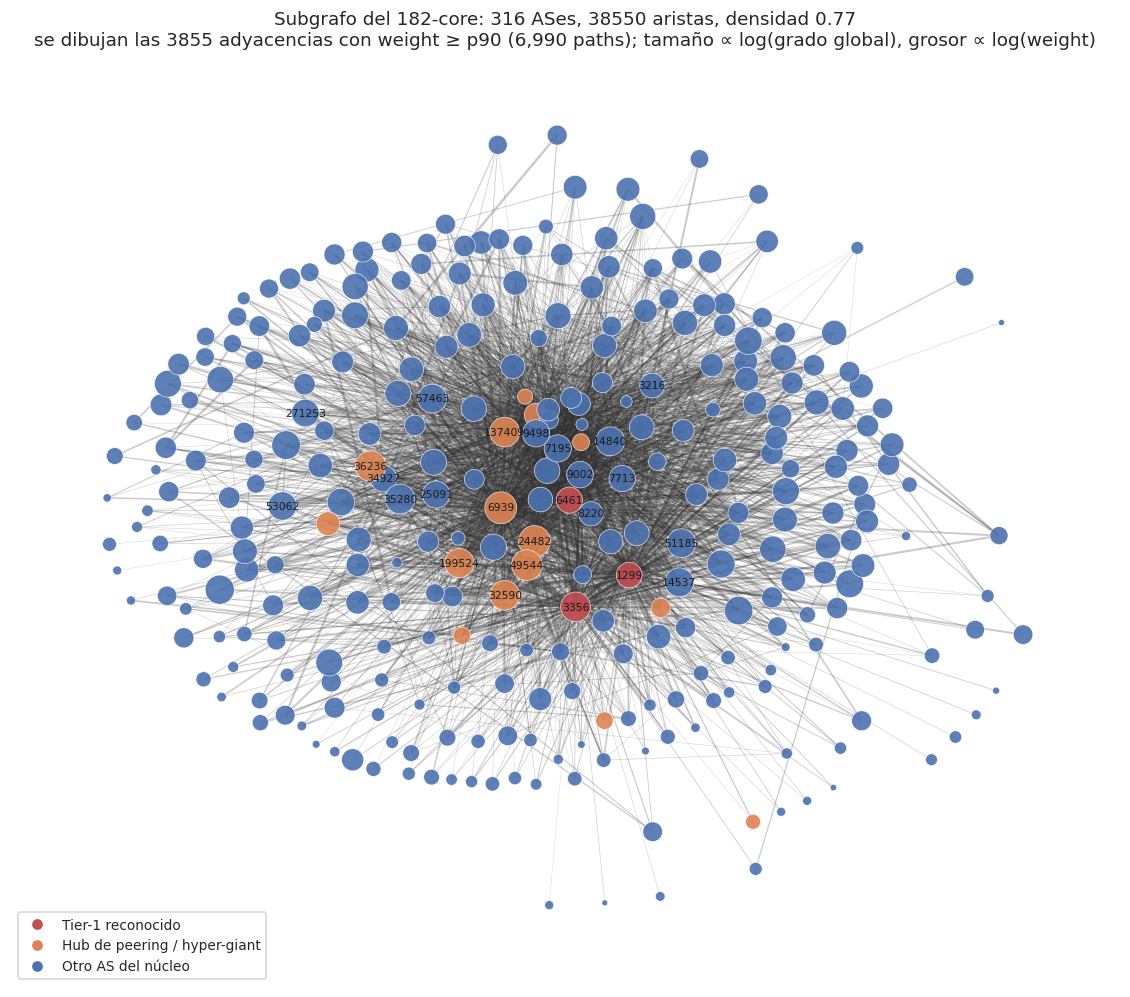

In [20]:
# El k_max-core es casi un clique: se dibujan sólo las adyacencias del percentil EDGE_PCT de `weight`
# (las que concentran los paths BGP), lo que revela la columna vertebral de tránsito dentro del núcleo.
EDGE_PCT = 90
w_core = np.array([d.get("weight", 1) for _, _, d in K.edges(data=True)])
w_thr = np.percentile(w_core, EDGE_PCT)
K_bb = nx.Graph()
K_bb.add_edges_from((u, v, {"lw": math.log10(d["weight"] + 1)}) for u, v, d in K.edges(data=True) if d.get("weight", 1) >= w_thr)
K_bb = K_bb.subgraph(max(nx.connected_components(K_bb), key=len)).copy()
omitted = sorted(set(K.nodes) - set(K_bb.nodes))
print(f"{len(omitted)} ASes del núcleo sin adyacencias en el decil superior de weight (no se dibujan): {omitted}")
pos = nx.kamada_kawai_layout(K_bb)      # ~300 nodos: KK coloca los hubs de tránsito al centro

deg_full = np.array([degree[NODE_INDEX[n]] for n in K_bb.nodes])
sizes = 15 + 420 * (np.log10(deg_full) - np.log10(deg_full.min())) / max(np.log10(deg_full.max()) - np.log10(deg_full.min()), 1e-9)
colors = ["#C44E52" if n in TIER1 else "#DD8452" if n in PEERING_HUBS else "#4C72B0" for n in K_bb.nodes]
ew = np.array([d["lw"] for _, _, d in K_bb.edges(data=True)])
ew = 0.2 + 2.0 * (ew - ew.min()) / max(ew.max() - ew.min(), 1e-9)

fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx_edges(K_bb, pos, ax=ax, width=ew, alpha=0.25, edge_color="#333333")
nx.draw_networkx_nodes(K_bb, pos, ax=ax, node_size=sizes, node_color=colors, alpha=0.9, linewidths=0.4, edgecolors="white")
label_nodes = [n for n in core_table.index[:25]] + sorted(set(K_bb.nodes) & TIER1)
nx.draw_networkx_labels(K_bb, {n: pos[n] for n in label_nodes}, labels={n: f"{n}" for n in label_nodes}, font_size=7, ax=ax)
handles = [Line2D([], [], marker="o", ls="", color="#C44E52", label="Tier-1 reconocido"),
           Line2D([], [], marker="o", ls="", color="#DD8452", label="Hub de peering / hyper-giant"),
           Line2D([], [], marker="o", ls="", color="#4C72B0", label="Otro AS del núcleo")]
ax.legend(handles=handles, loc="lower left", fontsize=9)
ax.set_title(f"Subgrafo del {k_max}-core: {K.number_of_nodes()} ASes, {K.number_of_edges()} aristas, densidad {nx.density(K):.2f}\n"
             f"se dibujan las {K_bb.number_of_edges()} adyacencias con weight ≥ p{EDGE_PCT} ({w_thr:,.0f} paths); tamaño ∝ log(grado global), grosor ∝ log(weight)")
ax.axis("off")
savefig("06_kmax_core")
plt.show()

### 6.1 Grado vs intermediación por capa de coreness

Combina las tres señales estructurales: la coreness separa periferia (colores fríos) de núcleo
(cálidos); dentro del núcleo, la intermediación distingue backbones de tránsito de hubs de peering.

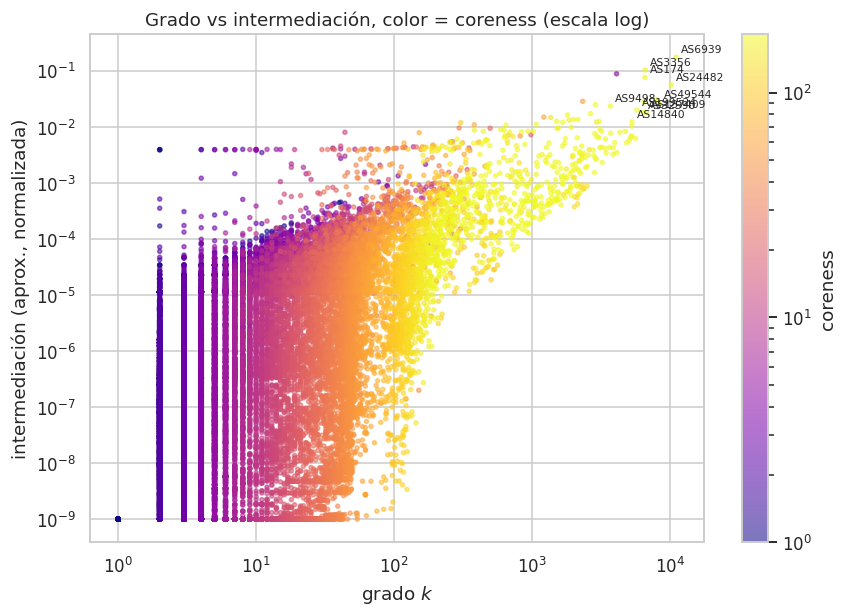

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
order = np.argsort(core_arr)      # dibuja el núcleo encima
sc = ax.scatter(degree[order], cent.loc[NODES[order], "betweenness"].values + 1e-9, c=core_arr[order],
                cmap="plasma", s=7, alpha=0.55, norm=LogNorm(vmin=1, vmax=k_max))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("grado $k$"); ax.set_ylabel("intermediación (aprox., normalizada)")
ax.set_title("Grado vs intermediación, color = coreness (escala log)")
for asn in top15.index[:10]:
    ax.annotate(f"AS{asn}", (cent.at[asn, "grado"], cent.at[asn, "betweenness"] + 1e-9), fontsize=7, xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc, ax=ax, label="coreness")
savefig("06_grado_betweenness_coreness")
plt.show()

## 7. Resumen y conclusiones para ingeniería de redes BGP

In [22]:
summary = pd.concat([
    macro_df.rename(columns={"valor": "valor"}),
    fit_summary.loc[["gamma (MLE discreto)", "k_min óptimo (KS)", "distancia KS", "p-valor de Vuong"]],
    clustering_df,
])
summary.index.name = "métrica"
summary["valor"] = summary["valor"].astype(object)
summary.to_csv(FIG_DIR / "07_resumen_metricas.csv")
display(summary)
print(f"Figuras y tablas guardadas en {FIG_DIR.resolve()}")

,valor
métrica,
|V| nodos (ASNs),"87,794"
|E| aristas (adyacencias),"663,404"
densidad,0.000172141
grado promedio <k>,15.1127
grado mediano,2
grado máximo,"11,090"
<k^2> / <k>^2 (heterogeneidad),84.8553
fracción de nodos con k = 1 (stubs single-homed),0.392612
fracción de nodos con k <= 2,0.658724


Figuras y tablas guardadas en /home/vale/Escritorio/GIT/LABORATORIO/gnn-as-relationships/notebooks/results/analysis_as_topology


**Conclusiones.**

1. **Small-world disperso**: densidad $\sim 10^{-4}$ y distancia media de ~3–4 saltos AS. Cualquier
   prefijo es alcanzable con pocos `AS_PATH` hops porque el tránsito converge en un núcleo compacto.
2. **Cola pesada / scale-free**: $\gamma \approx 2$ (MLE discreto). La heterogeneidad de grado es
   extrema y la prueba de Vuong típicamente no distingue power-law de log-normal; la conclusión
   operativa es la concentración de la conectividad, no el nombre de la distribución.
3. **Jerarquía disasortativa**: $r < 0$, $C(k) \sim k^{-1}$ y $\bar{C} \gg C$: los stubs cuelgan de
   proveedores que peerean entre sí; el tránsito es un árbol "aplanado" por el peering en IXPs.
4. **Núcleo identificable sin etiquetas**: el $k_{\max}$-core y el ranking compuesto de centralidades
   recuperan a la mayoría de los Tier-1 y a los hyper-giants. La discrepancia entre grado (hubs de
   open peering) e intermediación / fuerza (backbones) es exactamente la ambigüedad que un clasificador
   P2P / P2C debe resolver, y sugiere usar **fuerza, coreness e intermediación como features
   estructurales** además del grado.
5. **Implicancias para la GNN**: los hubs de $k > 5\,000$ dominan cualquier agregación de vecinos
   full-batch; conviene muestreo de vecindarios (`LinkNeighborLoader`) y normalización simétrica o
   por grado. La 1-shell (stubs single-homed) aporta poca información topológica propia y su relación
   se infiere casi enteramente de su único proveedor.

**Referencias.** Faloutsos, Faloutsos & Faloutsos, *On Power-Law Relationships of the Internet
Topology*, SIGCOMM 1999 · Clauset, Shalizi & Newman, *Power-law distributions in empirical data*,
SIAM Review 2009 · Newman, *Assortative mixing in networks*, PRL 2002 · Ravasz & Barabási,
*Hierarchical organization in complex networks*, PRE 2003 · Carmi et al., *A model of Internet
topology using k-shell decomposition*, PNAS 2007 · Brandes & Pich, *Centrality estimation in large
networks*, IJBC 2007 · Gao, *On inferring autonomous system relationships in the Internet*, ToN 2001.